In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [ ]:
#1 import data

In [ ]:
conn = sqlite3.connect('customer_churn.db')

sql_query = '''
    SELECT name
    FROM sqlite_master
    WHERE type='table'
'''

tables = pd.read_sql(sql_query, conn)

for table_name in tables['name']:
    df = pd.read_sql(f"select * from {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"created dataframe: df_{table_name}")

conn.close()
    




created dataframe: df_db_customer
created dataframe: df_db_subscription
created dataframe: df_db_support


In [ ]:
# print table name and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable name: {table_name}")
    
    # get column information
    column_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(column_query, conn)
    
    print("Columns:")
    print(columns['name'].tolist())

# close connection
conn.close()



Table name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [ ]:
# data cleaning


In [ ]:
# df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [ ]:
df_db_customer.info()


<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [ ]:
# a drop column intrest - pincode
# b rename col - name
# c change datatype of dob
# d fix missing value in country
# e data standazation - gender




In [ ]:
# b rename col - name
df_db_customer.rename(columns = {'name' : ' customer_name'}, inplace = True )

In [ ]:
# a drop column intrest - pincode

#df_db_customer.drop(df_db_customer.columns[-2:], axis=1,  )
#df_db_customer.columns[-2:]

df_db_customer.drop(columns = ['interests','pincode' ], inplace = True)


In [ ]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      21 non-null     str  
 1    customer_name  21 non-null     str  
 2   country         18 non-null     str  
 3   state           21 non-null     str  
 4   gender          21 non-null     str  
 5   dob             21 non-null     str  
dtypes: str(6)
memory usage: 1.1 KB


In [ ]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [ ]:
# e data standazation - gender
#df_db_customer['gender']. unique()

df_db_customer['gender']=df_db_customer['gender'].replace({'Men' : 'Male' , 'Women' : 'Female'})
                               

In [ ]:
# d fix missing value in country
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [ ]:
# country and state unique value pair
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [ ]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [ ]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [ ]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()


<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [ ]:
#df_db_subscription.drop(columns = ['interests','pincode' ], inplace = True)

df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [ ]:
df_db_support.drop(columns = ['comment'], inplace = True)

In [ ]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [ ]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
 4   col_1           0 non-null      object        
dtypes: datetime64[us](1), int64(1), object(1), str(2)
memory usage: 492.0+ bytes


In [ ]:
# feature engineering and data analysis

In [ ]:
# create a new column using existing columns
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [ ]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [ ]:
# first fix support table dublicates
df = (df_db_subscription
    .merge(df_db_customer, on='customerid', how='left')
    .merge(df_db_customer, on='customerid', how='left'))

In [ ]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name_x,country_x,state_x,gender_x,dob_x,customer_name_y,country_y,state_y,gender_y,dob_y
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,mira,India,Delhi,Female,1990-05-05


In [ ]:
#df.shape
df_db_subscription['customerid'].nunique()

21

In [ ]:
df_db_customer['customerid'].nunique()

21

In [ ]:
df_db_support['customerid'].nunique()

7

In [ ]:
df_db_support['customerid'].size

9

In [ ]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')
    

In [ ]:
df_db_support['complaint_count']

0    2
1    2
2    1
3    1
4    1
5    1
6    1
7    2
8    2
Name: complaint_count, dtype: int64

In [ ]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [ ]:
df_db_support['customerid'].size

7

In [ ]:
# merge df
df = (df_db_subscription
    .merge(df_db_customer, on='customerid', how='left')
    .merge(df_db_support, on='customerid', how='left'))

In [ ]:
df.shape

(21, 22)

In [ ]:
df.to_csv('exported_churn_data.csv', index=False)

In [ ]:
# data analysis

In [ ]:
# churn_rate

In [ ]:
df['churn_flag'].mean()

np.float64(0.2857142857142857)

In [ ]:
churn_rate = df['churn_flag'].mean()*100
print('churn_rate =', round(churn_rate,2), "%")

churn_rate = 28.57 %


In [ ]:
# retention_rate

In [ ]:
retention_rate = 100 - churn_rate

print('retention_rate =', round(retention_rate,2), "%")

retention_rate = 71.43 %


In [ ]:
# churn_plan_type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)              

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [ ]:
# churn by state and + sum of revenue and count of users
# churn by subscribtion type + sum of revenue and count of users

print(df.columns.tolist())

['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'complaint_count', 'churn_risk']


In [ ]:
churn_by_state = (
    df.groupby('state')
    .agg(
        churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
        total_revenue=('monthly_charges', 'sum'),
        user_count=('customerid', 'count')
    )
    .reset_index()
)
print(churn_by_state)


           state  churn_rate_pct  total_revenue  user_count
0          Delhi           25.00          52.96           4
1      Karnataka          100.00          20.98           2
2      Kathmandu            0.00          20.98           2
3    Maharashtra            0.00          50.97           3
4      Meghalaya           66.67          42.97           3
5       Nagaland            0.00          22.99           1
6      Rajasthan            0.00          36.98           2
7      Telangana           50.00          30.98           2
8  Uttar Pradesh            0.00         115.98           2


In [ ]:
# churn by subscription type + sum of revenue and count of users
churn_by_subscription = (
    df.groupby('subscription_type')
    .agg(
        churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
        total_revenue=('monthly_charges', 'sum'),
        user_count=('customerid', 'count')
    )
    .reset_index()
)
print(churn_by_subscription)

  subscription_type  churn_rate_pct  total_revenue  user_count
0           Organic            0.00         145.91           9
1              Paid           16.67         174.94           6
2          Refferal           83.33          74.94           6


In [ ]:
# ARPU - AVG reveune per users
arpu = df['monthly_charges'].mean()

print('ARPU =', round(arpu,2))

ARPU = 18.85


In [ ]:
# average customer tenure
# counts of days customer used our services : cancellation date else currect date

today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print('avg tenure (days)= ' ,round(avg_tenure,0) )

avg tenure (days)=  1548.0


In [ ]:
# revune at risk - revune loss at churn users
revune_at_risk = df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("revune at risk (Rs 'K') =" ,revune_at_risk)

revune at risk (Rs 'K') = 73.94


In [ ]:
# Escalation Rate
escalations_rate = (df['escalations']=='Y').mean()*100

print("Escalation Rate = " , round(escalations_rate, 2), '%')

Escalation Rate =  0.0 %


In [ ]:
# avg complaint per users

avg_complaint = df['complaint_count'].sum() / df['customerid'].nunique()

print("avg complaint per users =" , round(avg_complaint,2))


avg complaint per users = 0.43


In [ ]:
# correlation Escalation vs churn

df['escalations'] = np.where(df['escalations'] =='Y',1, 0) # encoding syn to int type

corr_df = df[['escalations' , 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])

print("Correlation Between Escalation vs Churn is = ",  round(correlation,2))





Correlation Between Escalation vs Churn is =  nan


C:\Users\ansar\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\ansar\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
print(df['escalations'].unique())
print(corr_df['escalations'].value_counts())
print(corr_df['churn_flag'].value_counts())

[0]
escalations
0    21
Name: count, dtype: int64
churn_flag
0    15
1     6
Name: count, dtype: int64


In [ ]:
print(df_db_support['escalations'].unique())  # or whichever original df/table had it, before overwriting

<StringArray>
['Y', 'N']
Length: 2, dtype: str


In [ ]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', ' customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'col_1',
       'complaint_count'],
      dtype='str')

In [ ]:

df.head()


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,col_1,complaint_count,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,NaN,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,None,2.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,NaN,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,NaN,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,None,1.0,high


In [ ]:
print(df.columns.tolist())

['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', ' customer_name', 'country', 'state', 'gender', 'dob', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'complaint_count']


In [ ]:
print(df['escalations'].dtype)

int64


In [ ]:
print(df_db_subscription.columns.tolist())
print(df_db_customer.columns.tolist())
print(df_db_support.columns.tolist())

['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag']
['customerid', ' customer_name', 'country', 'state', 'gender', 'dob']
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'complaint_count']


In [ ]:
df = (df_db_subscription
    .merge(df_db_customer, on='customerid', how='left')
    .merge(df_db_support, on='customerid', how='left'))

df.columns = df.columns.str.strip()  # fixes the ' customer_name' whitespace issue
print(df.columns.tolist())
print(df['escalations'].unique())  # should show ['Y', 'N'] — raw, not yet encoded

['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'complaint_count']
<StringArray>
[nan, 'Y', 'N']
Length: 3, dtype: str


In [ ]:
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0)

In [ ]:
corr_df = df[['escalations', 'churn_flag']].dropna()
correlation = corr_df['escalations'].corr(corr_df['churn_flag'])
print("Correlation between Escalation vs Churn is =", round(correlation, 2))

Correlation between Escalation vs Churn is = nan


In [ ]:
print(df['escalations'].value_counts())
print(corr_df['escalations'].value_counts())
print(corr_df['churn_flag'].value_counts())
print(len(corr_df))

escalations
0    21
Name: count, dtype: int64
escalations
0    21
Name: count, dtype: int64
churn_flag
0    15
1     6
Name: count, dtype: int64
21


In [ ]:
# 1. Load/reload your source tables (df_db_subscription, df_db_customer, df_db_support)

# 2. Merge
df = (df_db_subscription
    .merge(df_db_customer, on='customerid', how='left')
    .merge(df_db_support, on='customerid', how='left'))

# 3. Clean column names
df.columns = df.columns.str.strip()

# 4. Verify raw values BEFORE encoding
print(df['escalations'].unique())  # should show [nan, 'Y', 'N']

# 5. Encode — run this cell only ONCE
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0)

# 6. Verify encoding worked
print(df['escalations'].value_counts())  # should show both 0s and 1s

# 7. Correlation
corr_df = df[['escalations', 'churn_flag']].dropna()
correlation = corr_df['escalations'].corr(corr_df['churn_flag'])
print("Correlation between Escalation vs Churn is =", round(correlation, 2))

<StringArray>
[nan, 'Y', 'N']
Length: 3, dtype: str
escalations
0    17
1     4
Name: count, dtype: int64
Correlation between Escalation vs Churn is = 0.77


In [ ]:
# churn risk created a colum using exsisting col
Condition = (
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
)

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(Condition, choices, default='unknown')
    


In [ ]:
df[['churn_risk','churn_score']].head()

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88


In [ ]:
# visualization using matplotlib

In [ ]:
df_visual = df.copy()

In [ ]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,col_1,complaint_count,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,NaN,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,None,2.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,NaN,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,NaN,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,None,1.0,high


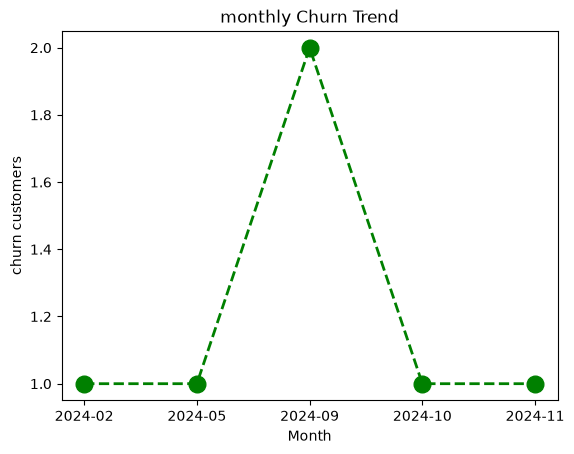

In [ ]:
# monthly churn trend( time series KPI)

#visual['cancellation_month']= df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', linestyle='dashed',linewidth=2, markersize=12)

plt.title('monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('churn customers')
plt.show()

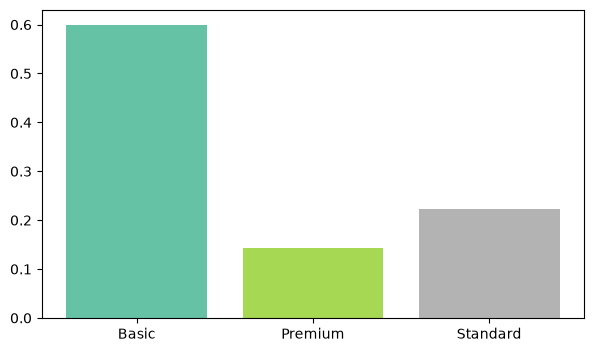

In [ ]:
# churn by plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colour = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color=colour )
plt.show()

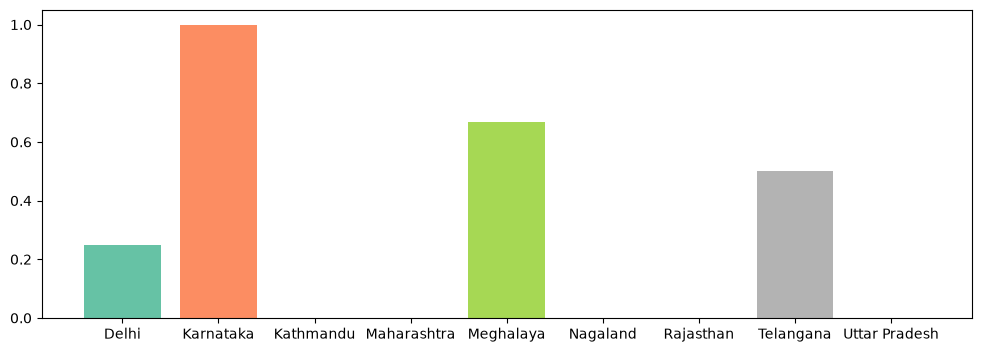

In [ ]:
# churn by state type

churn_plan = df_visual.groupby('state')['churn_flag'].mean()

colour = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color=colour )
plt.show()

In [ ]:
# visualization by seaborn

In [ ]:
# encoding -- convert str to numeric value so we can find corr bedtween feature

df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'col_1',
       'complaint_count', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [ ]:
#df_encoded =
df_visual[['plan_type', 'contract_type', 'churn_score',
       'churn_flag','escalations','churn_risk']].head()



,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Standard,Annual,12,0,0,low
1,Premium,Annual,91,1,1,high
2,Basic,Monthly,34,0,0,low
3,Premium,Annual,8,0,0,low
4,Standard,Monthly,88,1,1,high


In [ ]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,2,0,12,0,0,1
1,1,0,91,1,1,0
2,0,1,34,0,0,1
3,1,0,8,0,0,1
4,2,1,88,1,1,0


In [ ]:
#incorrect method of encoding - as numbers are not assigned based on piroty

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score','churn_flag','escalations','churn_risk']]

categorial_cols = ['plan_type','contract_type','churn_risk']


for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes
    




<Axes: >

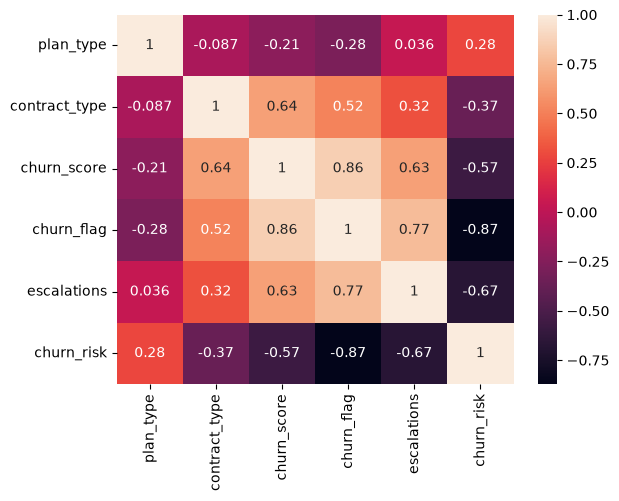

In [ ]:
# headmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

In [ ]:
df_visual['churn_risk'].unique()

<StringArray>
['low', 'high', 'med']
Length: 3, dtype: str

In [ ]:

# correct method on encoding -  based on priority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score','churn_flag','escalations','churn_risk']]

order_mapping = {
    'plan_type' : ['Basic','Standard','Premium'],
    'contract_type' :['Monthly','Annual'],
    'churn_risk' : ['low','med','high']
}


for col , order in order_mapping.items():
    df_encoded[col] = pd.Categorical(df_encoded[col], categories=order, ordered=True).codes

In [ ]:
df_visual[['plan_type', 'contract_type', 'churn_score','churn_flag','escalations','churn_risk']].head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Standard,Annual,12,0,0,low
1,Premium,Annual,91,1,1,high
2,Basic,Monthly,34,0,0,low
3,Premium,Annual,8,0,0,low
4,Standard,Monthly,88,1,1,high


In [ ]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,1,1,12,0,0,0
1,2,1,91,1,1,2
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,1,2


<Axes: >

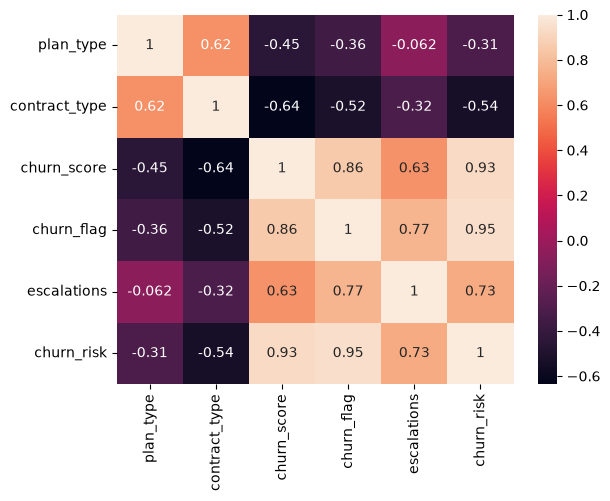

In [ ]:
# headmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

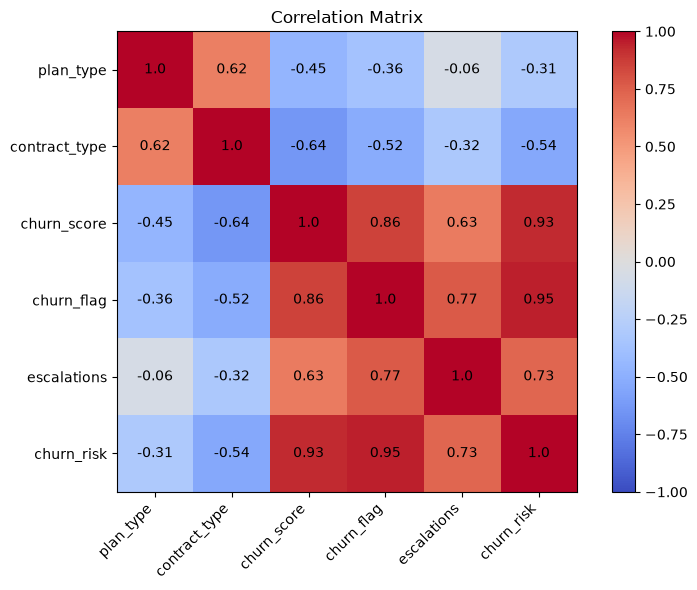

In [ ]:


corr = df_encoded.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

# axis labels
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

# annotate each cell with its correlation value
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, round(corr.iloc[i, j], 2), ha='center', va='center', color='black')

# colorbar
fig.colorbar(im, ax=ax)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

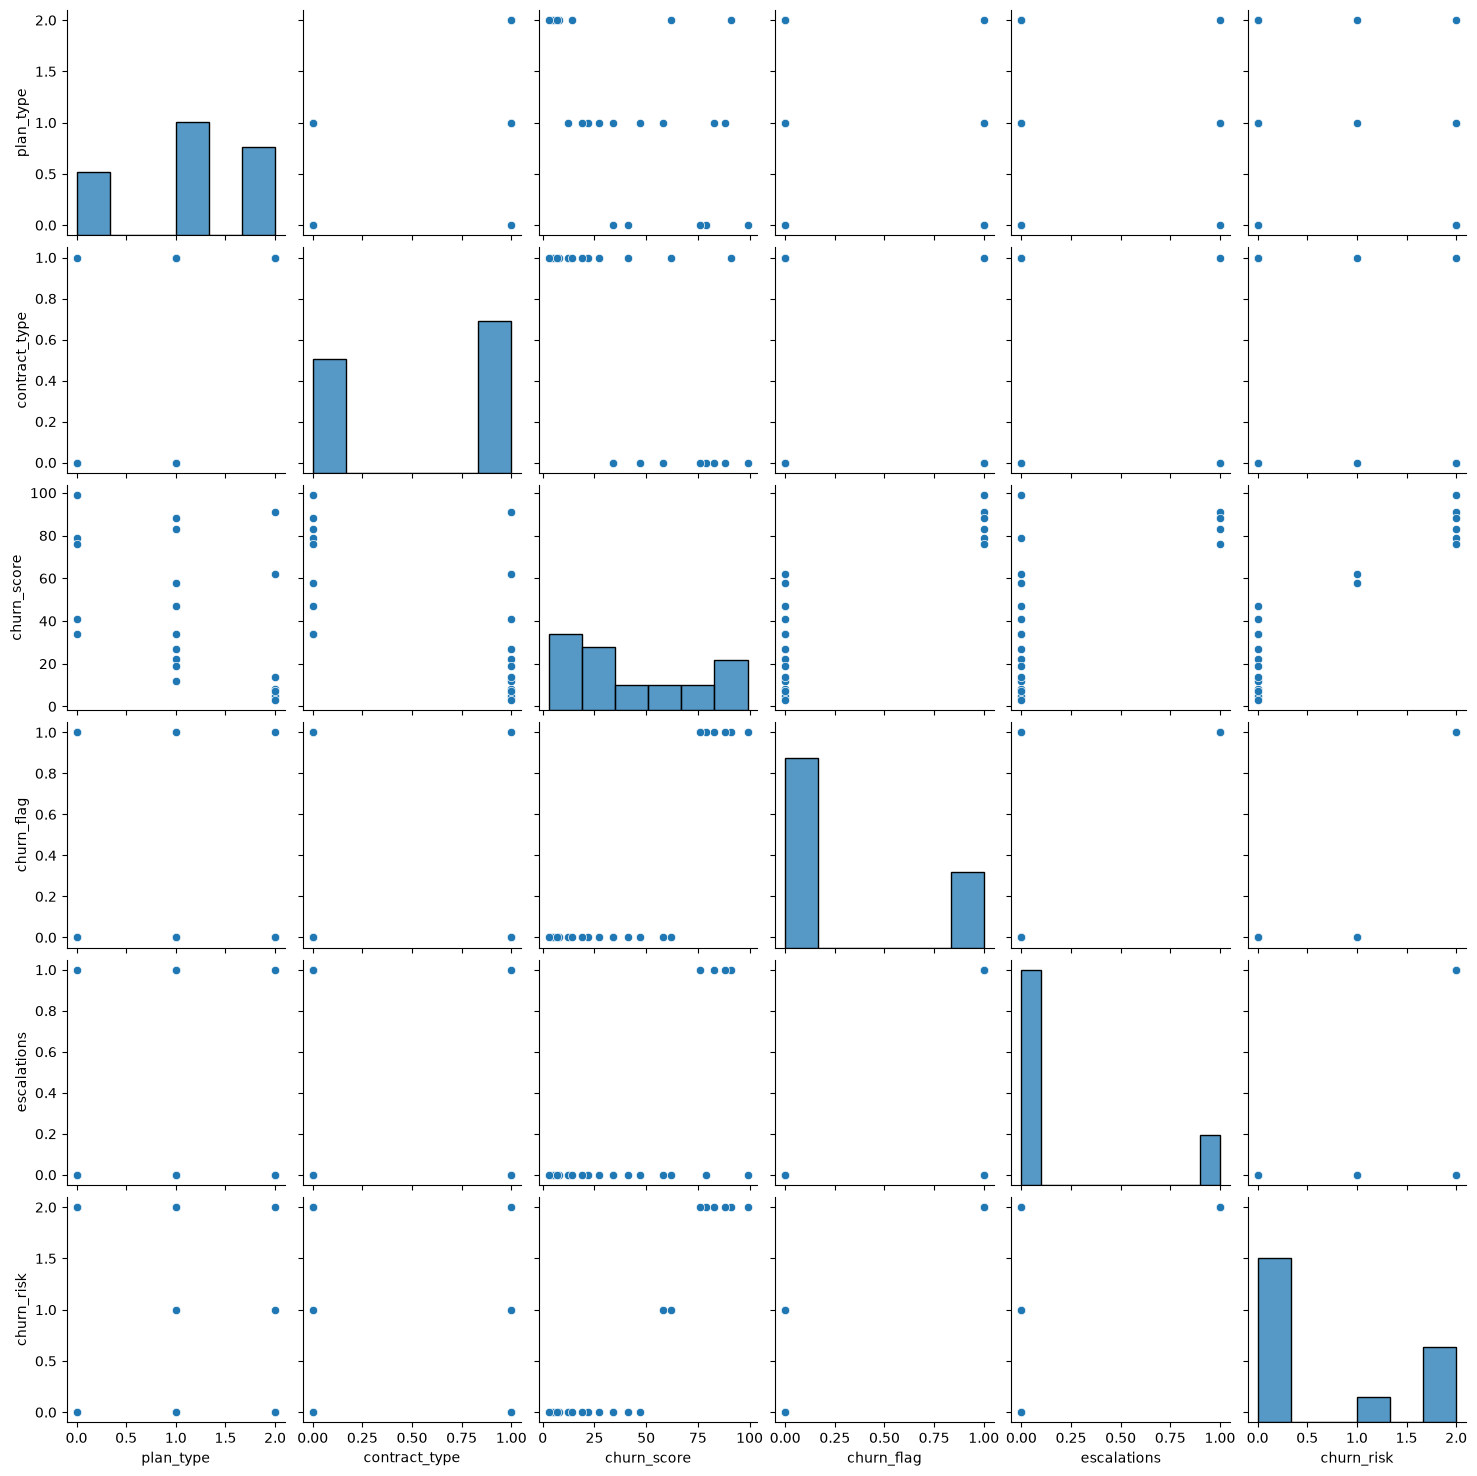

In [ ]:
# pairplot relationship between dataset

sns.pairplot(df_encoded)

In [ ]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'col_1',
       'complaint_count', 'churn_risk', 'cancellation_month'],
      dtype='str')

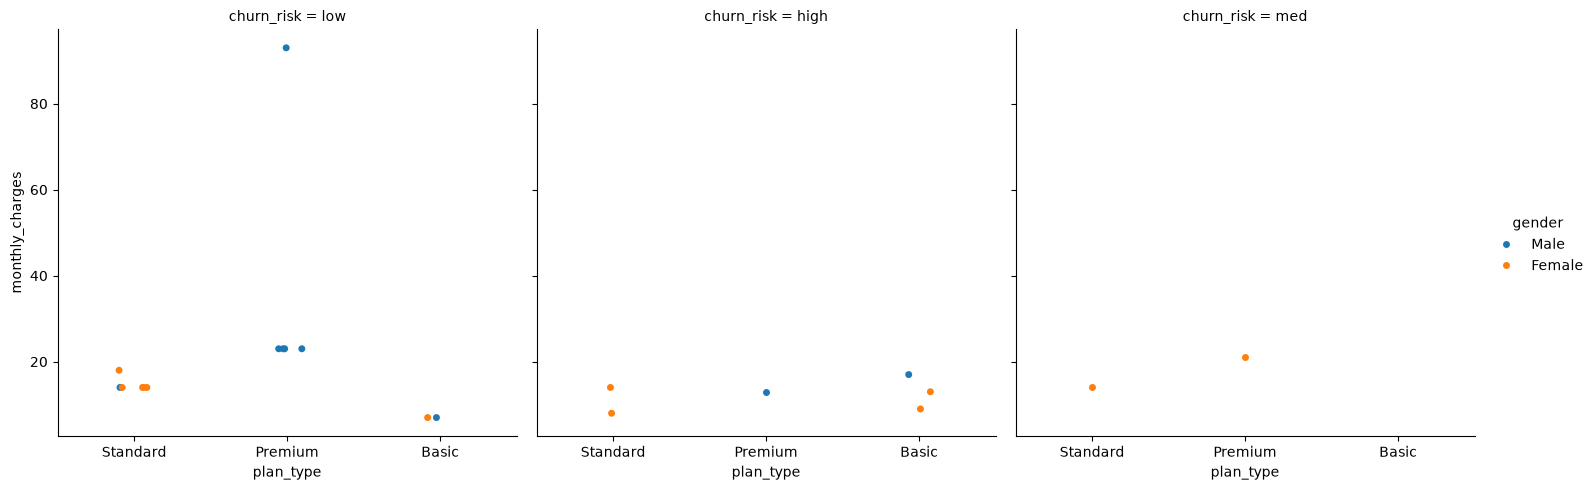

In [ ]:
# catplt/facegrid plot---- multi dim comparison
sns.catplot(data=df_visual,
           x='plan_type',
           y='monthly_charges',
           hue='gender',
           col='churn_risk')

In [ ]:
# pivot table

In [ ]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc='mean').reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [ ]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'col_1',
       'complaint_count', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [ ]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges','customerid','churn_flag'],
    aggfunc={
    'monthly_charges' : 'sum',
    'customerid': 'nunique',
    'churn_flag' : 'mean'}
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91
